# Import and Model Loading:

In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from xray.interpretability import *

c:\Users\megha\Desktop\xray-transformers\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#IMPORTS:

import torch
import matplotlib.pyplot as plt

from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer
)

from xray.interpretability import DistilBertInterpreter

# LOAD THE HUGGINGFACE MODEL:

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = DistilBertForSequenceClassification.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
).to(device)

tokenizer = DistilBertTokenizer.from_pretrained(
    "JDsouza1/distilbert-imdb-sentiment"
)

print("Model loaded!")

Device: cpu


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 11666.42it/s]


Model loaded!


In [12]:
# CREATE THE INTERPRETER:

interpreter = DistilBertInterpreter(
    model,
    tokenizer,
    device
)

# Test Cases:

In [4]:
test_texts = [
    "This movie was absolutely fantastic and I loved every minute of it.",
    "This movie was terrible, boring, and completely disappointing.",
    "This was not a bad movie at all.",
    "The acting was excellent, but the story was painfully boring.",
    "I expected this movie to be terrible, but it was actually wonderful.",
    "What a fantastic movie... if you enjoy falling asleep."
]

for i, text in enumerate(test_texts, 1):
    print(f"{i}. {text}")

1. This movie was absolutely fantastic and I loved every minute of it.
2. This movie was terrible, boring, and completely disappointing.
3. This was not a bad movie at all.
4. The acting was excellent, but the story was painfully boring.
5. I expected this movie to be terrible, but it was actually wonderful.
6. What a fantastic movie... if you enjoy falling asleep.


# Original Predictions:

In [5]:
def predict_text(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=-1)

    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0, predicted_class].item()

    return predicted_class, confidence

In [6]:
original_results = []

for text in test_texts:
    prediction, confidence = predict_text(text)

    original_results.append({
        "text": text,
        "prediction": prediction,
        "label": "POSITIVE" if prediction == 1 else "NEGATIVE",
        "confidence": confidence
    })

original_df = pd.DataFrame(original_results)

original_df

,text,prediction,label,confidence
0,This movie was absolutely fantastic and I love...,1,POSITIVE,0.995928
1,"This movie was terrible, boring, and completel...",0,NEGATIVE,0.997209
2,This was not a bad movie at all.,1,POSITIVE,0.825081
3,"The acting was excellent, but the story was pa...",0,NEGATIVE,0.978495
4,"I expected this movie to be terrible, but it w...",1,POSITIVE,0.986044
5,What a fantastic movie... if you enjoy falling...,1,POSITIVE,0.989481


# Word Removal Perturbation:

In [21]:
text = test_texts[0]

words = text.split()

original_prediction, original_confidence = predict_text(text)

perturbation_results = []

for i, word in enumerate(words):
    perturbed_words = words[:i] + words[i+1:]
    perturbed_text = " ".join(perturbed_words)

    prediction, confidence = predict_text(perturbed_text)

    perturbation_results.append({
        "removed_word": word,
        "perturbed_text": perturbed_text,
        "prediction": prediction,
        "confidence": confidence,
        "confidence_change": confidence - original_confidence
    })

perturbation_df = pd.DataFrame(perturbation_results)

perturbation_df.head()

,removed_word,perturbed_text,prediction,confidence,confidence_change
0,This,movie was absolutely fantastic and I loved eve...,1,0.995387,-0.000540
1,movie,This was absolutely fantastic and I loved ever...,1,0.995328,-0.000599
2,was,This movie absolutely fantastic and I loved ev...,1,0.996060,0.000132
3,absolutely,This movie was fantastic and I loved every min...,1,0.996027,0.000100
4,fantastic,This movie was absolutely and I loved every mi...,1,0.995801,-0.000127


# Get attribution:

In [ ]:
def get_word_attributions(text):
    """
    Generate word-level Integrated Gradients
    for a given input sentence.
    """

    attribution_result = interpreter.attribute(text)

    tokens = attribution_result["tokens"]
    attributions = attribution_result["token_attributions"]
    delta = attribution_result["convergence_delta"]
    input_output = attribution_result["input_output"]
    baseline_output = attribution_result["baseline_output"]
    total_attribution = attribution_result["total_attribution"]
    completeness_error = attribution_result["completeness_error"]
    
    words, scores = interpreter.aggregate_tokens(
        tokens,
        attributions
        )

    return words, scores

# Align IG Attribution with deletion effect:
Do words receiving high IG attribution actually have a larger effect when removed?

Measure attribution/deletion correlation:

In [20]:
from scipy.stats import spearmanr
# Spearman correlation because we're interested in whether words ranked highly 
# by IG also tend to have larger deletion effects.

In [18]:
def evaluate_deletion_faithfulness(text):
    # Get IG word-level attributions
    words, attributions = get_word_attributions(text)

    # Original prediction
    original_prediction, original_confidence = predict_text(text)

    results = []

    for i, word in enumerate(words):
        # Remove exactly one word
        perturbed_words = words[:i] + words[i+1:]
        perturbed_text = " ".join(perturbed_words)

        prediction, confidence = predict_text(perturbed_text)

        results.append({
            "word": word,
            "attribution": float(attributions[i]),
            "deletion_effect": original_confidence - confidence
        })

    df = pd.DataFrame(results)

    # Spearman correlation between IG ranking and deletion effect
    correlation, p_value = spearmanr(
        df["attribution"],
        df["deletion_effect"]
    )

    return df, correlation, p_value

In [19]:
comparison_df, correlation, p_value = evaluate_deletion_faithfulness(
    test_texts[0]
)

print(f"Spearman correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

comparison_df

Spearman correlation: 0.4011
P-value: 0.1744


,word,attribution,deletion_effect
0,this,0.217276,0.000540
1,movie,0.148403,0.000599
2,was,0.045538,-0.000132
3,absolutely,0.234302,-0.000100
4,fantastic,0.472755,0.000127
5,and,0.427234,0.000259
6,i,0.217258,0.000118
7,loved,0.485604,0.000914
8,every,0.038579,0.000231
9,minute,0.014611,-0.000164


# Run faithfulness evaluation across all test cases:

In [22]:
faithfulness_results = []

for text in test_texts:
    comparison_df, correlation, p_value = evaluate_deletion_faithfulness(text)

    prediction, confidence = predict_text(text)

    faithfulness_results.append({
        "text": text,
        "prediction": "POSITIVE" if prediction == 1 else "NEGATIVE",
        "confidence": confidence,
        "spearman_correlation": correlation,
        "p_value": p_value,
        "num_words": len(comparison_df)
    })

faithfulness_df = pd.DataFrame(faithfulness_results)

faithfulness_df

,text,prediction,confidence,spearman_correlation,p_value,num_words
0,This movie was absolutely fantastic and I love...,POSITIVE,0.995928,0.401099,0.174357,13
1,"This movie was terrible, boring, and completel...",NEGATIVE,0.997209,0.481818,0.133434,11
2,This was not a bad movie at all.,POSITIVE,0.825081,0.133333,0.732368,9
3,"The acting was excellent, but the story was pa...",NEGATIVE,0.978495,0.552448,0.062511,12
4,"I expected this movie to be terrible, but it w...",POSITIVE,0.986044,0.468132,0.091376,14
5,What a fantastic movie... if you enjoy falling...,POSITIVE,0.989481,0.850842,0.000227,13


# Target class logit prediction:

Do words that IG considers important also cause a larger decrease in the model's target-class logit when deleted?

In [23]:
def predict_target_logit(text, target_class):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.logits[0, target_class].item()

# Top k Deletion Curve:

In [27]:
def top_k_deletion_curve(text, max_k=None):
    words, attributions = get_word_attributions(text)

    prediction, _ = predict_text(text)
    original_logit = predict_target_logit(text, prediction)

    # Rank words by absolute attribution
    ranked_indices = np.argsort(
        -np.abs(np.array(attributions))
    )

    if max_k is None:
        max_k = len(words)

    results = []

    for k in range(1, max_k + 1):
        remove_indices = set(ranked_indices[:k])

        remaining_words = [
            word for i, word in enumerate(words)
            if i not in remove_indices
        ]

        perturbed_text = " ".join(remaining_words)

        perturbed_logit = predict_target_logit(
            perturbed_text,
            prediction
        )

        results.append({
            "k": k,
            "removed_words": [
                words[i] for i in ranked_indices[:k]
            ],
            "target_logit": perturbed_logit,
            "logit_drop": original_logit - perturbed_logit
        })

    return pd.DataFrame(results)

In [28]:
text = test_texts[0]

deletion_curve_df = top_k_deletion_curve(text)

deletion_curve_df

,k,removed_words,target_logit,logit_drop
0,1,[loved],2.534976,0.107415
1,2,"[loved, fantastic]",2.262455,0.379936
2,3,"[loved, fantastic, and]",1.871523,0.770867
3,4,"[loved, fantastic, and, absolutely]",0.816622,1.825768
4,5,"[loved, fantastic, and, absolutely, it]",0.036953,2.605437
5,6,"[loved, fantastic, and, absolutely, it, .]",-0.194135,2.836525
6,7,"[loved, fantastic, and, absolutely, it, ., this]",-0.802613,3.445004
7,8,"[loved, fantastic, and, absolutely, it, ., thi...",-0.290626,2.933017
8,9,"[loved, fantastic, and, absolutely, it, ., thi...",-0.126509,2.768900
9,10,"[loved, fantastic, and, absolutely, it, ., thi...",-0.168534,2.810924


# Random Deletion Baseline:

In [34]:
def random_deletion_curve(text, max_k=None, seed=42):
    words, attributions = get_word_attributions(text)

    prediction, _ = predict_text(text)
    original_logit = predict_target_logit(text, prediction)

    rng = np.random.default_rng(seed)

    indices = np.arange(len(words))
    rng.shuffle(indices)

    if max_k is None:
        max_k = len(words)

    results = []

    for k in range(1, max_k + 1):
        remove_indices = set(indices[:k])

        remaining_words = [
            word for i, word in enumerate(words)
            if i not in remove_indices
        ]

        perturbed_text = " ".join(remaining_words)

        perturbed_logit = predict_target_logit(
            perturbed_text,
            prediction
        )

        results.append({
            "k": k,
            "removed_words": [
                words[i] for i in indices[:k]
            ],
            "target_logit": perturbed_logit,
            "logit_drop": original_logit - perturbed_logit
        })

    return pd.DataFrame(results)

In [35]:
seeds = range(10)

random_curves = []

for seed in seeds:
    curve_df = random_deletion_curve(
        test_texts[0],
        seed=seed
    )

    curve_df["seed"] = seed
    random_curves.append(curve_df)

random_curves_df = pd.concat(
    random_curves,
    ignore_index=True
)

random_curves_df.head()

,k,removed_words,target_logit,logit_drop,seed
0,1,[of],2.658943,-0.016553,0
1,2,"[of, was]",2.665954,-0.023563,0
2,3,"[of, was, loved]",2.677900,-0.035510,0
3,4,"[of, was, loved, fantastic]",2.498763,0.143628,0
4,5,"[of, was, loved, fantastic, and]",2.240190,0.402200,0


In [36]:
# Mean random curve:
mean_random_curve = (
    random_curves_df
    .groupby("k")["logit_drop"]
    .mean()
    .reset_index()
)

mean_random_curve

,k,logit_drop
0,1,0.002342
1,2,0.009088
2,3,0.027939
3,4,0.084971
4,5,0.222719
5,6,0.246077
6,7,0.429378
7,8,0.750909
8,9,0.989170
9,10,1.276973


# Quantify the curves:

Because we're currently using one fixed random ordering, this is only a demonstration, not a robust quantitative benchmark.

Later, we'll improve it by running multiple random seeds and compare IG against the mean random curve.


In [37]:
ig_auc = np.trapezoid(
    deletion_curve_df["logit_drop"],
    deletion_curve_df["k"]
)

random_auc = np.trapezoid(
    mean_random_curve["logit_drop"],
    mean_random_curve["k"]
)

print(f"IG deletion AUC: {ig_auc:.4f}")
print(f"Mean random deletion AUC: {random_auc:.4f}")
print(f"Difference: {ig_auc - random_auc:.4f}")

IG deletion AUC: 26.4868
Mean random deletion AUC: 9.6602
Difference: 16.8266


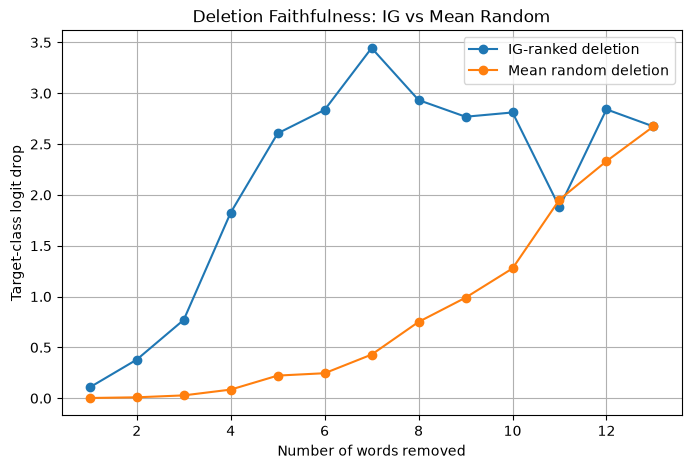

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    deletion_curve_df["k"],
    deletion_curve_df["logit_drop"],
    marker="o",
    label="IG-ranked deletion"
)

plt.plot(
    mean_random_curve["k"],
    mean_random_curve["logit_drop"],
    marker="o",
    label="Mean random deletion"
)

plt.xlabel("Number of words removed")
plt.ylabel("Target-class logit drop")
plt.title("Deletion Faithfulness: IG vs Mean Random")
plt.legend()
plt.grid(True)

plt.show()

# Experiment across all 6 testcases:

In [39]:
all_faithfulness_results = []

for i, text in enumerate(test_texts):

    print(f"Processing example {i + 1}/{len(test_texts)}...")

    # IG-ranked deletion
    ig_curve = top_k_deletion_curve(text)

    # Multiple random deletion runs
    random_curves = []

    for seed in range(10):
        random_curve = random_deletion_curve(
            text,
            seed=seed
        )
        random_curves.append(random_curve)

    random_df = pd.concat(
        random_curves,
        ignore_index=True
    )

    # Mean random curve
    mean_random_curve = (
        random_df
        .groupby("k")["logit_drop"]
        .mean()
        .reset_index()
    )

    # AUCs
    ig_auc = np.trapezoid(
        ig_curve["logit_drop"],
        ig_curve["k"]
    )

    random_auc = np.trapezoid(
        mean_random_curve["logit_drop"],
        mean_random_curve["k"]
    )

    prediction, confidence = predict_text(text)

    all_faithfulness_results.append({
        "example": i + 1,
        "text": text,
        "prediction": "POSITIVE" if prediction == 1 else "NEGATIVE",
        "confidence": confidence,
        "ig_auc": ig_auc,
        "random_auc": random_auc,
        "auc_difference": ig_auc - random_auc
    })

all_faithfulness_df = pd.DataFrame(
    all_faithfulness_results
)

all_faithfulness_df

Processing example 1/6...
Processing example 2/6...
Processing example 3/6...
Processing example 4/6...
Processing example 5/6...
Processing example 6/6...


,example,text,prediction,confidence,ig_auc,random_auc,auc_difference
0,1,This movie was absolutely fantastic and I love...,POSITIVE,0.995928,26.486804,9.660206,16.826598
1,2,"This movie was terrible, boring, and completel...",NEGATIVE,0.997209,27.197078,7.898895,19.298184
2,3,This was not a bad movie at all.,POSITIVE,0.825081,14.844938,12.387735,2.457202
3,4,"The acting was excellent, but the story was pa...",NEGATIVE,0.978495,24.519052,10.914219,13.604834
4,5,"I expected this movie to be terrible, but it w...",POSITIVE,0.986044,50.754917,27.094186,23.660731
5,6,What a fantastic movie... if you enjoy falling...,POSITIVE,0.989481,34.522494,23.956121,10.566373


In [40]:
all_faithfulness_df["relative_difference_%"] = (
    (
        all_faithfulness_df["ig_auc"]
        - all_faithfulness_df["random_auc"]
    )
    / all_faithfulness_df["random_auc"].abs()
) * 100

all_faithfulness_df[
    [
        "example",
        "prediction",
        "confidence",
        "ig_auc",
        "random_auc",
        "auc_difference",
        "relative_difference_%"
    ]
]

,example,prediction,confidence,ig_auc,random_auc,auc_difference,relative_difference_%
0,1,POSITIVE,0.995928,26.486804,9.660206,16.826598,174.184673
1,2,NEGATIVE,0.997209,27.197078,7.898895,19.298184,244.314995
2,3,POSITIVE,0.825081,14.844938,12.387735,2.457202,19.835766
3,4,NEGATIVE,0.978495,24.519052,10.914219,13.604834,124.652383
4,5,POSITIVE,0.986044,50.754917,27.094186,23.660731,87.327705
5,6,POSITIVE,0.989481,34.522494,23.956121,10.566373,44.107196


# Experiment Aggregation:

In [41]:
summary = {
    "mean_ig_auc": all_faithfulness_df["ig_auc"].mean(),
    "median_ig_auc": all_faithfulness_df["ig_auc"].median(),
    "mean_random_auc": all_faithfulness_df["random_auc"].mean(),
    "median_random_auc": all_faithfulness_df["random_auc"].median(),
    "mean_auc_difference": all_faithfulness_df["auc_difference"].mean(),
    "median_auc_difference": all_faithfulness_df["auc_difference"].median()
}

summary

{'mean_ig_auc': np.float64(29.72088041373839),
 'median_ig_auc': np.float64(26.84194110147655),
 'mean_random_auc': np.float64(15.318560170869267),
 'median_random_auc': np.float64(11.650977040821452),
 'mean_auc_difference': np.float64(14.402320242869123),
 'median_auc_difference': np.float64(15.215715862327489)}

**IG beats Random**

In [42]:
ig_beats_random = (
    all_faithfulness_df["auc_difference"] > 0
).sum()

total_examples = len(all_faithfulness_df)

print(
    f"IG AUC > random AUC: "
    f"{ig_beats_random}/{total_examples} examples"
)

IG AUC > random AUC: 6/6 examples


**Overall IG Curve:**

In [43]:
all_ig_curves = []

for text in test_texts:
    curve = top_k_deletion_curve(text)

    curve["fraction_removed"] = (
        curve["k"] / curve["k"].max()
    )

    all_ig_curves.append(curve)

all_ig_curves_df = pd.concat(
    all_ig_curves,
    ignore_index=True
)

mean_ig_curve = (
    all_ig_curves_df
    .groupby("fraction_removed")["logit_drop"]
    .mean()
    .reset_index()
)

mean_ig_curve

,fraction_removed,logit_drop
0,0.071429,4.128600
1,0.076923,0.313515
2,0.083333,0.706943
3,0.090909,0.087183
4,0.111111,3.342650
5,0.142857,3.986634
6,0.153846,1.748171
7,0.166667,3.458835
8,0.181818,0.016328
9,0.214286,4.826022


**Overall Random Curve:**

In [44]:
all_random_curves = []

for text in test_texts:

    words, _ = get_word_attributions(text)

    for seed in range(10):

        curve = random_deletion_curve(
            text,
            seed=seed
        )

        curve["fraction_removed"] = (
            curve["k"] / curve["k"].max()
        )

        curve["seed"] = seed

        all_random_curves.append(curve)

all_random_curves_df = pd.concat(
    all_random_curves,
    ignore_index=True
)

mean_random_curve_overall = (
    all_random_curves_df
    .groupby("fraction_removed")["logit_drop"]
    .mean()
    .reset_index()
)

mean_random_curve_overall

,fraction_removed,logit_drop
0,0.071429,0.458320
1,0.076923,0.357000
2,0.083333,0.089510
3,0.090909,0.006328
4,0.111111,1.155061
5,0.142857,1.292052
6,0.153846,0.596052
7,0.166667,-0.093581
8,0.181818,0.024820
9,0.214286,1.520055


# **Plot Overall Curves:**

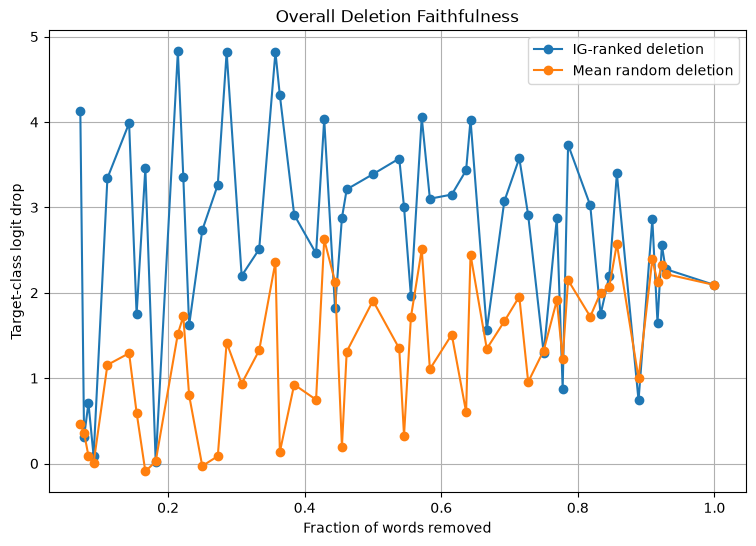

In [45]:
plt.figure(figsize=(9, 6))

plt.plot(
    mean_ig_curve["fraction_removed"],
    mean_ig_curve["logit_drop"],
    marker="o",
    label="IG-ranked deletion"
)

plt.plot(
    mean_random_curve_overall["fraction_removed"],
    mean_random_curve_overall["logit_drop"],
    marker="o",
    label="Mean random deletion"
)

plt.xlabel("Fraction of words removed")
plt.ylabel("Target-class logit drop")
plt.title("Overall Deletion Faithfulness")
plt.legend()
plt.grid(True)

plt.show()

What this figure means:
1. The x-axis represents how much of the text we've removed.
2. The y-axis represents how much the model's original predicted-class logit has decreased.
3. A curve that rises faster means that the method is identifying influential evidence earlier.

For our experiment, we expect the IG curve to generally lie above the random baseline during the early deletion stages.

# Add Variability to Random Baseline

A mean alone hides how much the random result varies.

Calculate the standard deviation across the 10 random seeds.

In [46]:
random_statistics = (
    all_random_curves_df
    .groupby("fraction_removed")["logit_drop"]
    .agg(["mean", "std"])
    .reset_index()
)

random_statistics.head()

,fraction_removed,mean,std
0,0.071429,0.458320,1.344152
1,0.076923,0.357000,0.866462
2,0.083333,0.089510,0.399229
3,0.090909,0.006328,0.042217
4,0.111111,1.155061,1.408071


Now plot the mean with ±1 standard deviation.

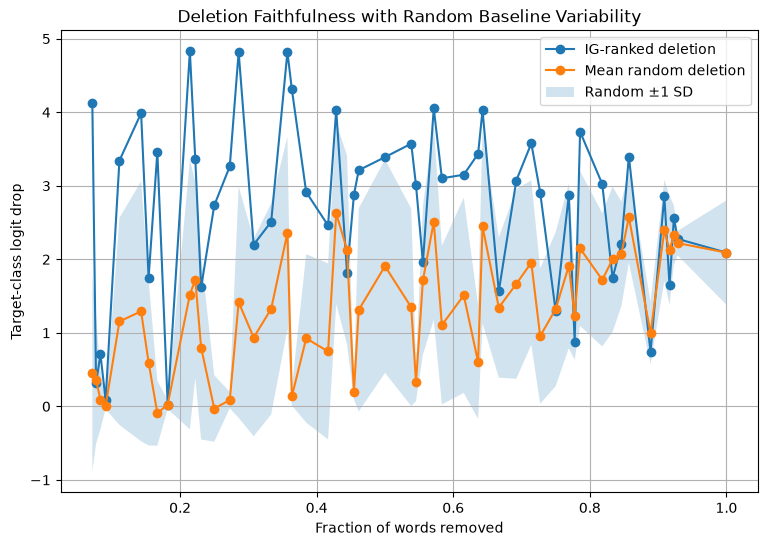

In [47]:
plt.figure(figsize=(9, 6))

x_ig = mean_ig_curve["fraction_removed"]
y_ig = mean_ig_curve["logit_drop"]

x_random = random_statistics["fraction_removed"]
y_random = random_statistics["mean"]
std_random = random_statistics["std"]

plt.plot(
    x_ig,
    y_ig,
    marker="o",
    label="IG-ranked deletion"
)

plt.plot(
    x_random,
    y_random,
    marker="o",
    label="Mean random deletion"
)

plt.fill_between(
    x_random,
    y_random - std_random,
    y_random + std_random,
    alpha=0.2,
    label="Random ±1 SD"
)

plt.xlabel("Fraction of words removed")
plt.ylabel("Target-class logit drop")
plt.title("Deletion Faithfulness with Random Baseline Variability")
plt.legend()
plt.grid(True)

plt.show()

Final Results Table

In [48]:
final_results = all_faithfulness_df[
    [
        "example",
        "prediction",
        "confidence",
        "ig_auc",
        "random_auc",
        "auc_difference"
    ]
].copy()

final_results["confidence"] = (
    final_results["confidence"].round(4)
)

final_results["ig_auc"] = (
    final_results["ig_auc"].round(4)
)

final_results["random_auc"] = (
    final_results["random_auc"].round(4)
)

final_results["auc_difference"] = (
    final_results["auc_difference"].round(4)
)

final_results

,example,prediction,confidence,ig_auc,random_auc,auc_difference
0,1,POSITIVE,0.9959,26.4868,9.6602,16.8266
1,2,NEGATIVE,0.9972,27.1971,7.8989,19.2982
2,3,POSITIVE,0.8251,14.8449,12.3877,2.4572
3,4,NEGATIVE,0.9785,24.5191,10.9142,13.6048
4,5,POSITIVE,0.9860,50.7549,27.0942,23.6607
5,6,POSITIVE,0.9895,34.5225,23.9561,10.5664


Overall Metrics:

In [49]:
mean_ig_auc = all_faithfulness_df["ig_auc"].mean()
mean_random_auc = all_faithfulness_df["random_auc"].mean()
mean_difference = all_faithfulness_df["auc_difference"].mean()

print(f"Mean IG deletion AUC: {mean_ig_auc:.4f}")
print(f"Mean random deletion AUC: {mean_random_auc:.4f}")
print(f"Mean AUC difference: {mean_difference:.4f}")
print(f"IG exceeded random in {ig_beats_random}/{total_examples} examples")

Mean IG deletion AUC: 29.7209
Mean random deletion AUC: 15.3186
Mean AUC difference: 14.4023
IG exceeded random in 6/6 examples


## Deletion-Based Faithfulness Evaluation

Integrated Gradients explanations were evaluated using a deletion-based
faithfulness experiment.

For each input text, words were ranked according to their absolute Integrated
Gradients attribution. Words were then removed progressively, and the model's
logit for the original predicted class was measured after each deletion.

The resulting deletion curve measures how quickly the model's target-class
evidence decreases when explanation-ranked words are removed.

A random deletion baseline was constructed using 10 different random seeds.
The mean random deletion curve provides a reference for comparison.

### Results

Across the six manually constructed test cases, the IG-ranked deletion
strategy produced a larger deletion AUC than the mean random baseline in
all six examples.

This indicates that, for this test set, words ranked highly by Integrated
Gradients tended to have a greater influence on the model's target-class
logit than words selected randomly.

The results should be interpreted as evidence from a small exploratory
evaluation rather than as a general claim about Integrated Gradients'
faithfulness.

### Important Observation

The negation example showed weaker alignment than several of the other
examples. This suggests that attribution behavior can be more challenging
for sentences whose sentiment depends on compositional linguistic structure,
such as negation.

The sarcasm-like example also demonstrates that explanation faithfulness and
prediction correctness are different properties. An explanation can
faithfully identify evidence used by the model even when the model's
prediction does not match the intended interpretation of the sentence.

## Limitations

This evaluation has several limitations:

1. **Small evaluation set**
   - Only six manually constructed sentences were evaluated.
   - The results are useful for demonstrating the evaluation methodology,
     but they are not sufficient to establish general performance.

2. **Single model**
   - The experiment evaluates one fine-tuned DistilBERT sentiment model.

3. **Random baseline**
   - Ten random seeds were used for the random deletion baseline.
   - More seeds would provide a more stable estimate for larger experiments.

4. **Word deletion**
   - Words are reconstructed using whitespace-separated tokens.
   - Removing words can change the resulting tokenization and sentence
     structure.

5. **Out-of-distribution perturbations**
   - Aggressively deleting words can create unnatural text.
   - Results at very high deletion levels should therefore be interpreted
     cautiously.

6. **Predicted-class evaluation**
   - The target logit is the model's original predicted class.
   - Consequently, faithfulness is evaluated with respect to what the model
     predicted, rather than an externally supplied ground-truth class.

7. **Correlation sample size**
   - Individual Spearman correlations were calculated using only the words
     within each sentence, resulting in small sample sizes.

## Methodology

The faithfulness evaluation follows a deletion-based perturbation approach:

1. Generate word-level Integrated Gradients attributions.
2. Rank words according to attribution magnitude.
3. Remove the highest-ranked words progressively.
4. Measure the target-class logit after each deletion.
5. Calculate the area under the resulting deletion curve.
6. Repeat deletion using randomly selected words.
7. Average the random baseline across 10 seeds.
8. Compare the IG-ranked and random deletion AUCs.

A larger early logit drop indicates that the removed words had greater
influence on the model's target-class output.